# 01 — Analyse Exploratoire des Données (EDA)
## Projet ObRail Europe — Prévision de fréquentation & Détection des pays en déclin

**Objectif** : Explorer les deux datasets ML produits par `build_dataset.py` afin de :
- Vérifier la qualité des données (valeurs manquantes, doublons, outliers)
- Comprendre la distribution des variables et de la cible
- Identifier les patterns temporels utiles à la modélisation
- Préparer les visualisations requises pour le rapport final

---
## 0. Imports et configuration

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Dossier de sauvegarde des figures
DOCS_DIR = Path("../../../../docs/ia/img")
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# Chemins des datasets ML
DATA_ML_DIR = Path("../../../../data/ml")
REGRESSION_DATASET_PATH    = DATA_ML_DIR / "regression_dataset.csv"
CLASSIF_DATASET_PATH       = DATA_ML_DIR / "classification_dataset.csv"

print("Régression dataset :", REGRESSION_DATASET_PATH.exists())
print("Classification dataset :", CLASSIF_DATASET_PATH.exists())

Régression dataset : True
Classification dataset : True


---
## 1. Chargement des datasets

In [2]:
df_reg = pd.read_csv(REGRESSION_DATASET_PATH)
df_clf = pd.read_csv(CLASSIF_DATASET_PATH)

print(f"Dataset régression    : {df_reg.shape[0]} lignes × {df_reg.shape[1]} colonnes")
print(f"Dataset classification : {df_clf.shape[0]} lignes × {df_clf.shape[1]} colonnes")

Dataset régression    : 595 lignes × 10 colonnes
Dataset classification : 595 lignes × 10 colonnes


In [3]:
# Aperçu régression
df_reg.head(10)

,country_id,country_name,year,year_id,co2_emissions,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2,passengers
0,1,Albania,2012,3,5658.180113,70.829068,5658.180113,79.8850,79.885,79.8850
1,1,Albania,2013,4,5658.180113,30.596334,5658.180113,79.8850,79.885,184.9300
2,1,Albania,2014,5,5658.180113,38.804360,5658.180113,184.9300,79.885,145.8130
3,1,Albania,2015,6,5658.180113,32.146559,5658.180113,145.8130,184.930,176.0120
4,1,Albania,2016,7,5658.180113,69.282707,5658.180113,176.0120,145.813,81.6680
5,1,Albania,2017,8,5658.180113,105.948509,5658.180113,81.6680,176.012,53.4050
6,1,Albania,2018,9,5658.180113,45.443580,5658.180113,53.4050,81.668,124.5100
7,1,Albania,2019,10,5658.180113,52.880188,5658.180113,124.5100,53.405,107.0000
8,1,Albania,2020,11,5658.180113,290.111012,5658.180113,107.0000,124.510,19.5035
9,1,Albania,2021,12,5658.180113,171.141059,5658.180113,19.5035,107.000,33.0615


In [4]:
# Aperçu classification
df_clf.head(10)

,country_id,country_name,year,year_id,co2_emissions,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2,en_declin
0,1,Albania,2012,3,5658.180113,70.829068,5658.180113,79.8850,79.885,0
1,1,Albania,2013,4,5658.180113,30.596334,5658.180113,79.8850,79.885,0
2,1,Albania,2014,5,5658.180113,38.804360,5658.180113,184.9300,79.885,0
3,1,Albania,2015,6,5658.180113,32.146559,5658.180113,145.8130,184.930,1
4,1,Albania,2016,7,5658.180113,69.282707,5658.180113,176.0120,145.813,1
5,1,Albania,2017,8,5658.180113,105.948509,5658.180113,81.6680,176.012,1
6,1,Albania,2018,9,5658.180113,45.443580,5658.180113,53.4050,81.668,0
7,1,Albania,2019,10,5658.180113,52.880188,5658.180113,124.5100,53.405,0
8,1,Albania,2020,11,5658.180113,290.111012,5658.180113,107.0000,124.510,1
9,1,Albania,2021,12,5658.180113,171.141059,5658.180113,19.5035,107.000,1


---
## 2. Qualité des données

### 2.1 Valeurs manquantes

In [5]:
print("=== Valeurs manquantes — Régression ===")
missing_reg = df_reg.isna().sum()
print(missing_reg[missing_reg > 0] if missing_reg.sum() > 0 else "Aucune valeur manquante ✅")

print("\n=== Valeurs manquantes — Classification ===")
missing_clf = df_clf.isna().sum()
print(missing_clf[missing_clf > 0] if missing_clf.sum() > 0 else "Aucune valeur manquante ✅")

=== Valeurs manquantes — Régression ===
Aucune valeur manquante ✅

=== Valeurs manquantes — Classification ===
Aucune valeur manquante ✅


### 2.2 Doublons

In [6]:
dup_reg = df_reg.duplicated().sum()
dup_clf = df_clf.duplicated().sum()

print(f"Doublons dataset régression    : {dup_reg}")
print(f"Doublons dataset classification : {dup_clf}")

Doublons dataset régression    : 0
Doublons dataset classification : 0


### 2.3 Statistiques descriptives

In [7]:
print("=== Statistiques descriptives — Régression ===")
df_reg.describe().round(2)

=== Statistiques descriptives — Régression ===


,country_id,year,year_id,co2_emissions,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2,passengers
count,595.00,595.00,595.00,595.00,595.00,595.00,595.00,595.00,595.00
mean,24.28,2017.97,8.97,5510.19,14.71,5537.29,124286.45,124715.15,124273.82
std,13.62,3.73,3.73,12182.63,136.87,12255.55,292426.80,294381.72,291601.80
min,1.00,2012.00,3.00,106.36,0.00,106.36,2.35,2.35,2.35
25%,13.00,2015.00,6.00,761.12,0.03,761.12,4304.42,4527.87,4181.67
50%,25.00,2018.00,9.00,2126.03,0.06,2126.03,17944.00,18049.00,17937.50
75%,36.00,2021.00,12.00,5637.87,0.20,5637.87,124787.48,124787.48,124787.48
max,47.00,2024.00,15.00,87972.48,2364.07,89632.47,2094374.13,2094374.13,2094374.13


In [8]:
print("=== Statistiques descriptives — Classification ===")
df_clf.describe().round(2)

=== Statistiques descriptives — Classification ===


,country_id,year,year_id,co2_emissions,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2,en_declin
count,595.00,595.00,595.00,595.00,595.00,595.00,595.00,595.00,595.00
mean,24.28,2017.97,8.97,5510.19,14.71,5537.29,124286.45,124715.15,0.36
std,13.62,3.73,3.73,12182.63,136.87,12255.55,292426.80,294381.72,0.48
min,1.00,2012.00,3.00,106.36,0.00,106.36,2.35,2.35,0.00
25%,13.00,2015.00,6.00,761.12,0.03,761.12,4304.42,4527.87,0.00
50%,25.00,2018.00,9.00,2126.03,0.06,2126.03,17944.00,18049.00,0.00
75%,36.00,2021.00,12.00,5637.87,0.20,5637.87,124787.48,124787.48,1.00
max,47.00,2024.00,15.00,87972.48,2364.07,89632.47,2094374.13,2094374.13,1.00


### 2.4 Couverture pays et années

In [9]:
print(f"Pays couverts  : {df_reg['country_name'].nunique()}")
print(f"Années couvertes: {df_reg['year'].min()} → {df_reg['year'].max()}")
print(f"\nListe des pays :")
print(sorted(df_reg['country_name'].unique()))

Pays couverts  : 46
Années couvertes: 2012 → 2024

Liste des pays :
['Albania', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'European Union (27)', 'Finland', 'France', 'GE', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro', 'Multiple Countries', 'Netherlands', 'North Macedonia', 'Norway', 'Other European Country', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'Ukraine', 'United Kingdom', 'Unknown Country']


---
## 3. Distribution de la cible régression : `passengers`

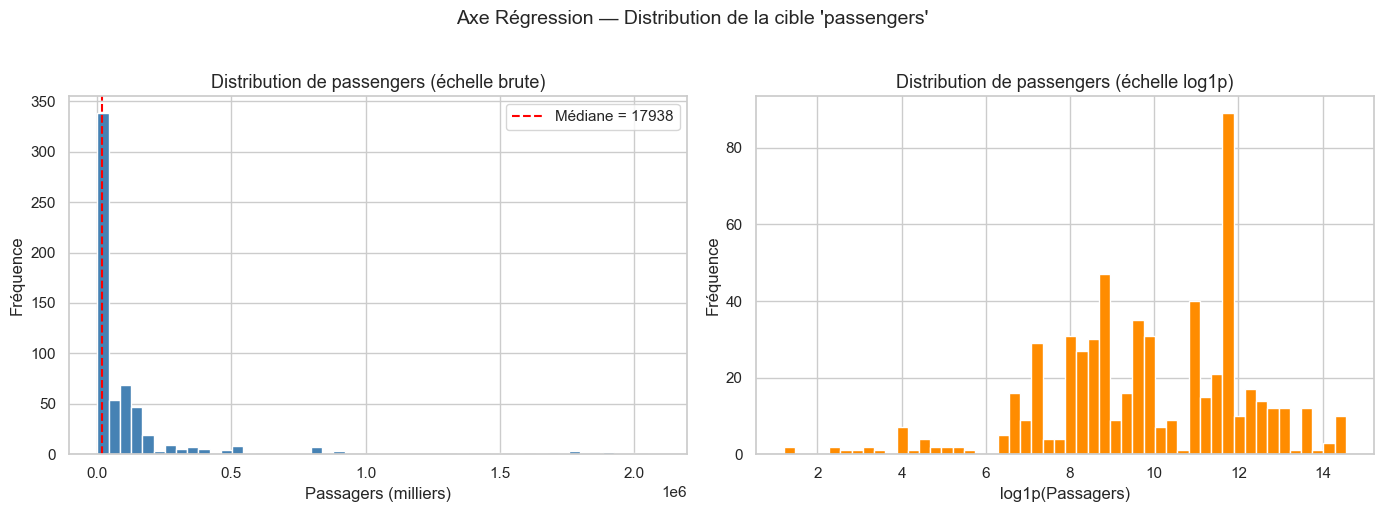

Figure sauvegardée : docs/fig_distribution_passengers.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df_reg["passengers"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de passengers (échelle brute)", fontsize=13)
axes[0].set_xlabel("Passagers (milliers)")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df_reg["passengers"].median(), color="red", linestyle="--",
                label=f"Médiane = {df_reg['passengers'].median():.0f}")
axes[0].legend()

# Distribution log1p (pour mieux visualiser l'asymétrie)
axes[1].hist(np.log1p(df_reg["passengers"]), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Distribution de passengers (échelle log1p)", fontsize=13)
axes[1].set_xlabel("log1p(Passagers)")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Axe Régression — Distribution de la cible 'passengers'", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_distribution_passengers.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_distribution_passengers.png")

In [11]:
# Statistiques clés de la cible régression
stats_passengers = df_reg["passengers"].describe()
print("Statistiques de 'passengers' :")
print(stats_passengers.round(0))
print(f"\nPart des observations > 100 000 : {(df_reg['passengers'] > 100_000).mean()*100:.1f}%")
print(f"Part des observations < 1 000   : {(df_reg['passengers'] < 1_000).mean()*100:.1f}%")

Statistiques de 'passengers' :
count        595.0
mean      124274.0
std       291602.0
min            2.0
25%         4182.0
50%        17938.0
75%       124787.0
max      2094374.0
Name: passengers, dtype: float64

Part des observations > 100 000 : 31.3%
Part des observations < 1 000   : 8.7%


---
## 4. Distribution de la cible classification : `en_declin`

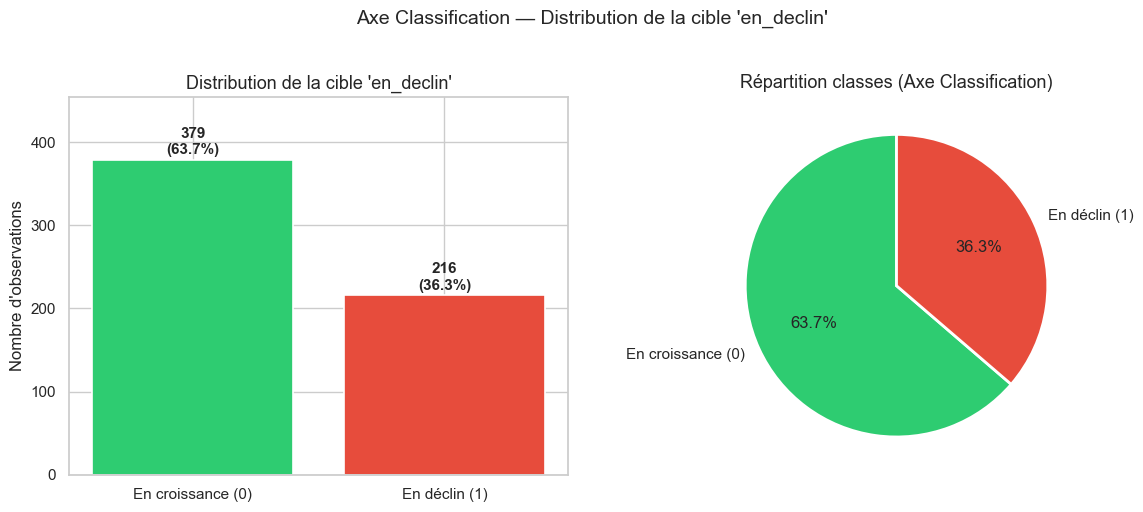

Figure sauvegardée : docs/fig_distribution_en_declin.png


In [12]:
counts = df_clf["en_declin"].value_counts()
labels = ["En croissance (0)", "En déclin (1)"]
colors = ["#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
bars = axes[0].bar(["En croissance (0)", "En déclin (1)"],
                   counts.values, color=colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f"{val}\n({val/len(df_clf)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Distribution de la cible 'en_declin'", fontsize=13)
axes[0].set_ylabel("Nombre d'observations")
axes[0].set_ylim(0, counts.max() * 1.2)

# Camembert
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Répartition classes (Axe Classification)", fontsize=13)

plt.suptitle("Axe Classification — Distribution de la cible 'en_declin'", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_distribution_en_declin.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_distribution_en_declin.png")

---
## 5. Évolution temporelle — Top 8 pays par fréquentation

In [13]:
# Identifier les 8 pays avec la fréquentation moyenne la plus élevée
top8_countries = (
    df_reg.groupby("country_name")["passengers"]
    .mean()
    .nlargest(8)
    .index.tolist()
)
print("Top 8 pays (fréquentation moyenne) :", top8_countries)

Top 8 pays (fréquentation moyenne) : ['European Union (27)', 'Germany', 'United Kingdom', 'France', 'Italy', 'Switzerland', 'Ukraine', 'Netherlands']


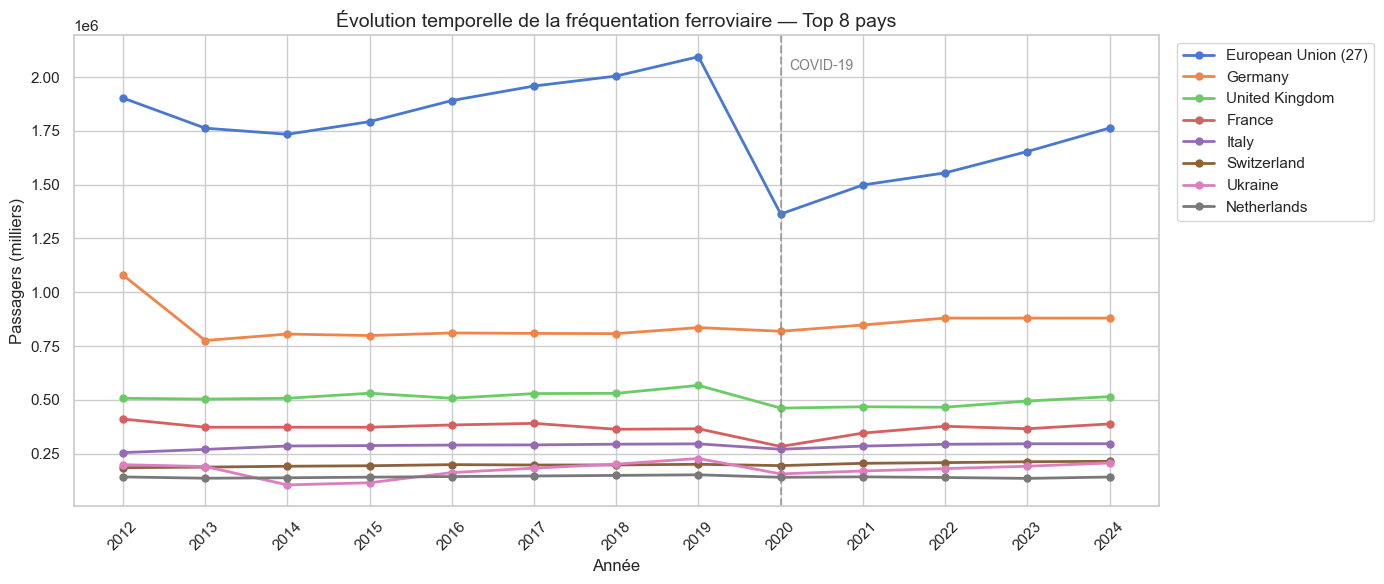

Figure sauvegardée : docs/fig_evolution_temporelle.png


In [14]:
df_top8 = df_reg[df_reg["country_name"].isin(top8_countries)]

fig, ax = plt.subplots(figsize=(14, 6))

for country in top8_countries:
    data = df_top8[df_top8["country_name"] == country].sort_values("year")
    ax.plot(data["year"], data["passengers"], marker="o", linewidth=2,
            markersize=5, label=country)

# Annotation COVID
ax.axvline(2020, color="gray", linestyle="--", alpha=0.6, linewidth=1.5)
ax.text(2020.1, ax.get_ylim()[1] * 0.95, "COVID-19", color="gray",
        fontsize=10, va="top")

ax.set_title("Évolution temporelle de la fréquentation ferroviaire — Top 8 pays",
             fontsize=14)
ax.set_xlabel("Année")
ax.set_ylabel("Passagers (milliers)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax.set_xticks(range(df_reg["year"].min(), df_reg["year"].max() + 1))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_evolution_temporelle.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_evolution_temporelle.png")

---
## 6. Matrice de corrélation des features numériques

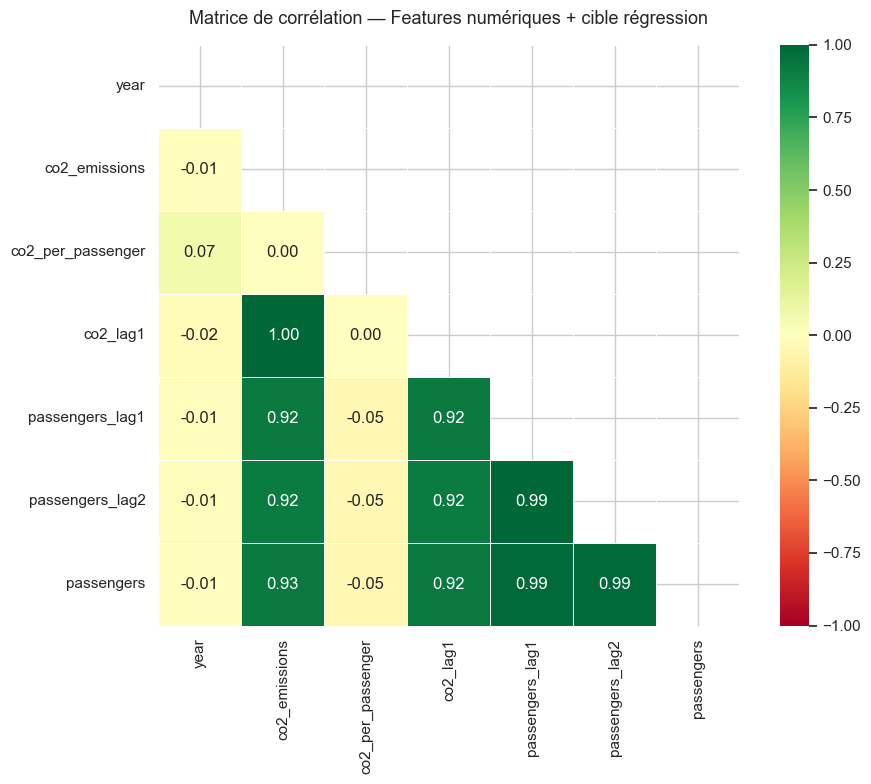

Figure sauvegardée : docs/fig_correlation_matrix.png


In [15]:
# Features numériques communes aux deux axes
numeric_features = [
    "year",
    "co2_emissions",
    "co2_per_passenger",
    "co2_lag1",
    "passengers_lag1",
    "passengers_lag2",
    "passengers",   # cible régression, pour voir la corrélation avec les features
]

corr = df_reg[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Masque triangle supérieur
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    mask=mask,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matrice de corrélation — Features numériques + cible régression",
             fontsize=13, pad=15)

plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_correlation_matrix.png")

In [16]:
# Corrélations avec la cible régression
print("Corrélation des features avec 'passengers' (cible régression) :")
corr_target = corr["passengers"].drop("passengers").sort_values(ascending=False)
print(corr_target.round(3))

Corrélation des features avec 'passengers' (cible régression) :
passengers_lag1      0.992
passengers_lag2      0.987
co2_emissions        0.926
co2_lag1             0.925
year                -0.005
co2_per_passenger   -0.046
Name: passengers, dtype: float64


---
## 7. Analyse des variables lag

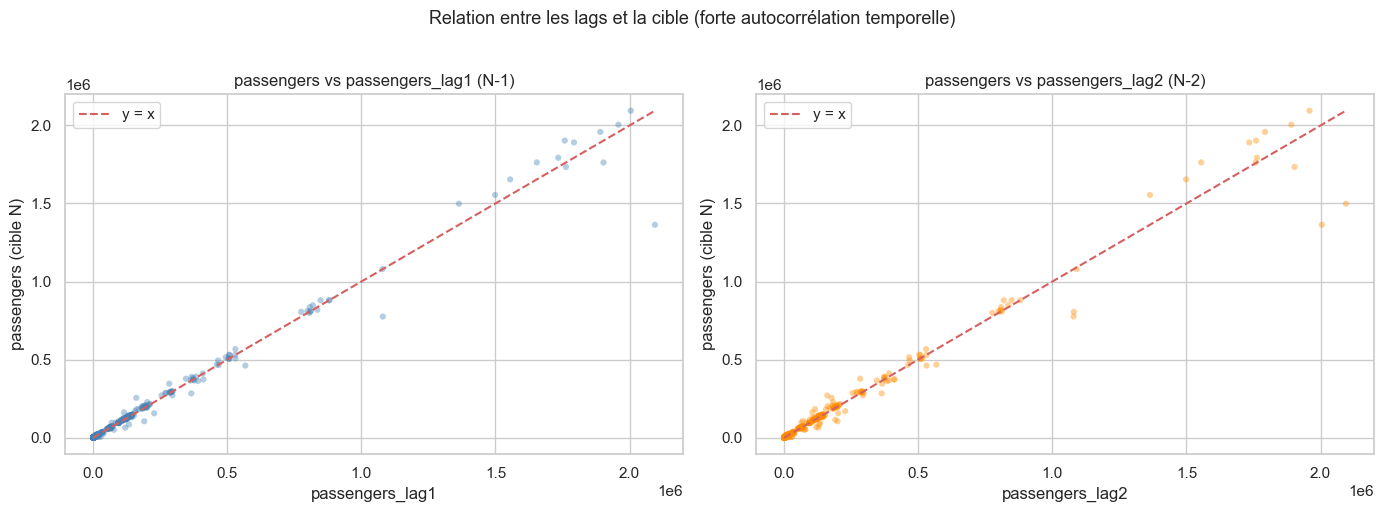

Figure sauvegardée : docs/fig_lag_scatter.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# passengers vs passengers_lag1
axes[0].scatter(df_reg["passengers_lag1"], df_reg["passengers"],
                alpha=0.4, color="steelblue", edgecolors="none", s=20)
# Droite y = x
max_val = df_reg[["passengers", "passengers_lag1"]].max().max()
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="y = x")
axes[0].set_title("passengers vs passengers_lag1 (N-1)", fontsize=12)
axes[0].set_xlabel("passengers_lag1")
axes[0].set_ylabel("passengers (cible N)")
axes[0].legend()

# passengers vs passengers_lag2
axes[1].scatter(df_reg["passengers_lag2"], df_reg["passengers"],
                alpha=0.4, color="darkorange", edgecolors="none", s=20)
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="y = x")
axes[1].set_title("passengers vs passengers_lag2 (N-2)", fontsize=12)
axes[1].set_xlabel("passengers_lag2")
axes[1].set_ylabel("passengers (cible N)")
axes[1].legend()

plt.suptitle("Relation entre les lags et la cible (forte autocorrélation temporelle)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_lag_scatter.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_lag_scatter.png")

---
## 8. Distribution de `en_declin` par année

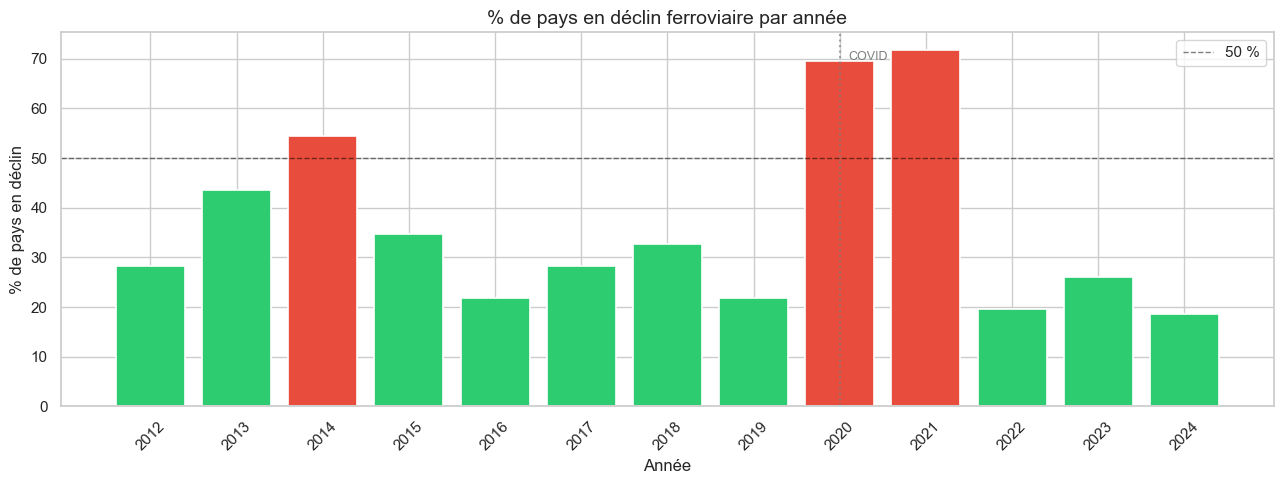

Figure sauvegardée : docs/fig_declin_par_annee.png

Détail par année :
      en_declin  total  pct_declin
year                              
2012         13     46        28.3
2013         20     46        43.5
2014         25     46        54.3
2015         16     46        34.8
2016         10     46        21.7
2017         13     46        28.3
2018         15     46        32.6
2019         10     46        21.7
2020         32     46        69.6
2021         33     46        71.7
2022          9     46        19.6
2023         12     46        26.1
2024          8     43        18.6


In [18]:
# Nombre de pays en déclin par année
declin_by_year = (
    df_clf.groupby("year")["en_declin"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "en_declin", "count": "total"})
)
declin_by_year["pct_declin"] = declin_by_year["en_declin"] / declin_by_year["total"] * 100

fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = ["#e74c3c" if p >= 50 else "#2ecc71" for p in declin_by_year["pct_declin"]]
bars = ax.bar(declin_by_year.index, declin_by_year["pct_declin"],
              color=colors_bar, edgecolor="white", linewidth=1.2)

ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5, label="50 %")
ax.set_title("% de pays en déclin ferroviaire par année", fontsize=14)
ax.set_xlabel("Année")
ax.set_ylabel("% de pays en déclin")
ax.set_xticks(declin_by_year.index)
ax.tick_params(axis="x", rotation=45)
ax.legend()

# Annotations COVID
ax.axvline(2020, color="gray", linestyle=":", alpha=0.7)
ax.text(2020.1, ax.get_ylim()[1] * 0.95, "COVID", color="gray", fontsize=9, va="top")

plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_declin_par_annee.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_declin_par_annee.png")
print("\nDétail par année :")
print(declin_by_year.round(1))

---
## 9. Distribution des émissions CO₂

C:\Users\loadj\AppData\Local\Temp\ipykernel_41476\297839013.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\loadj\AppData\Local\Temp\ipykernel_41476\297839013.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(DOCS_DIR / "fig_distribution_co2.png", bbox_inches="tight")
c:\Users\loadj\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


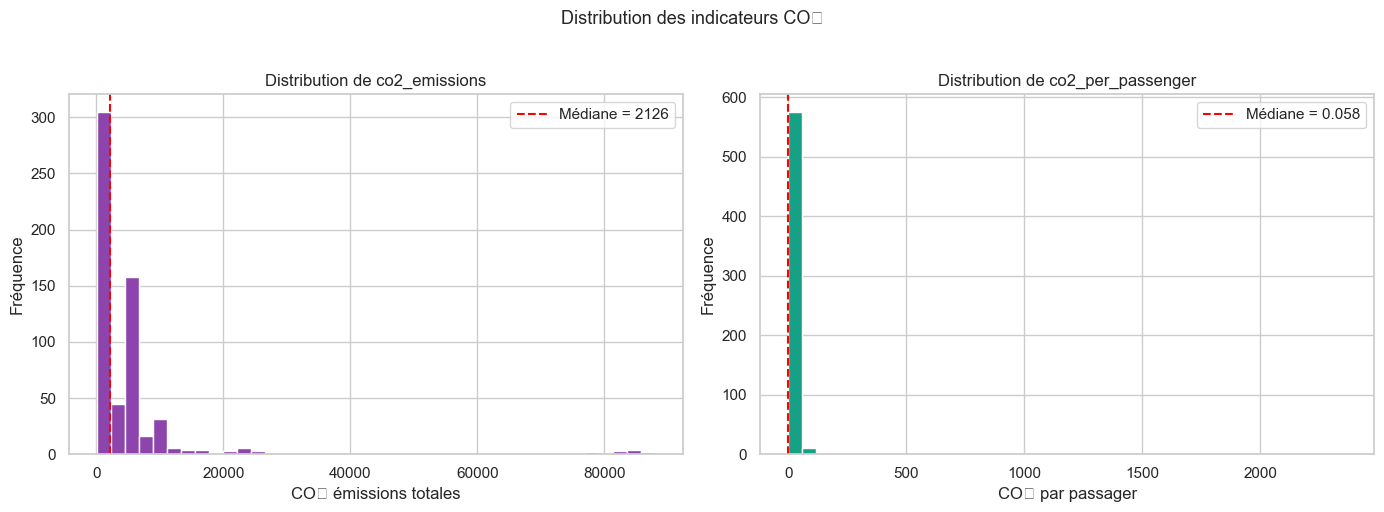

Figure sauvegardée : docs/fig_distribution_co2.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# co2_emissions
axes[0].hist(df_reg["co2_emissions"], bins=40, color="#8e44ad", edgecolor="white")
axes[0].set_title("Distribution de co2_emissions", fontsize=12)
axes[0].set_xlabel("CO₂ émissions totales")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df_reg["co2_emissions"].median(), color="red", linestyle="--",
                label=f"Médiane = {df_reg['co2_emissions'].median():.0f}")
axes[0].legend()

# co2_per_passenger
axes[1].hist(df_reg["co2_per_passenger"], bins=40, color="#16a085", edgecolor="white")
axes[1].set_title("Distribution de co2_per_passenger", fontsize=12)
axes[1].set_xlabel("CO₂ par passager")
axes[1].set_ylabel("Fréquence")
axes[1].axvline(df_reg["co2_per_passenger"].median(), color="red", linestyle="--",
                label=f"Médiane = {df_reg['co2_per_passenger'].median():.3f}")
axes[1].legend()

plt.suptitle("Distribution des indicateurs CO₂", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_distribution_co2.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_distribution_co2.png")

---
## 10. Boxplot des features numériques (détection d'outliers)

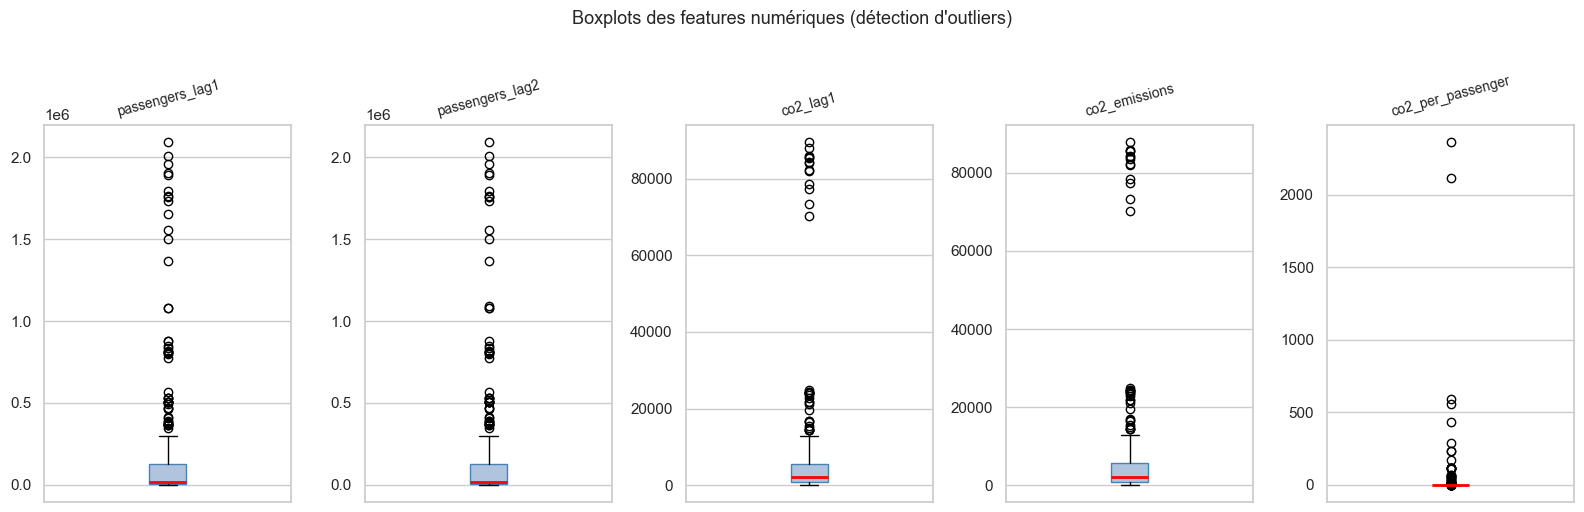

Figure sauvegardée : docs/fig_boxplots_features.png


In [20]:
lag_features = ["passengers_lag1", "passengers_lag2", "co2_lag1",
                "co2_emissions", "co2_per_passenger"]

fig, axes = plt.subplots(1, len(lag_features), figsize=(16, 5))

for ax, col in zip(axes, lag_features):
    ax.boxplot(df_reg[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", color="steelblue"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col, fontsize=10, rotation=15)
    ax.set_xticks([])

plt.suptitle("Boxplots des features numériques (détection d'outliers)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_boxplots_features.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_boxplots_features.png")

---
## 11. Résumé des observations EDA

In [21]:
print("=" * 60)
print("SYNTHÈSE EDA — PROJET OBRAIL EUROPE")
print("=" * 60)

print("\n📊 Datasets")
print(f"  Lignes (après suppression NaN lag) : {len(df_reg)}")
print(f"  Pays couverts                       : {df_reg['country_name'].nunique()}")
print(f"  Période                             : {df_reg['year'].min()}–{df_reg['year'].max()}")

print("\n🎯 Cible Régression (passengers)")
print(f"  Min      : {df_reg['passengers'].min():.0f}")
print(f"  Max      : {df_reg['passengers'].max():.0f}")
print(f"  Médiane  : {df_reg['passengers'].median():.0f}")
print(f"  → Distribution fortement asymétrique (skewed right)")

print("\n🎯 Cible Classification (en_declin)")
vc = df_clf["en_declin"].value_counts()
print(f"  Classe 0 (En croissance) : {vc[0]} ({vc[0]/len(df_clf)*100:.1f}%)")
print(f"  Classe 1 (En déclin)     : {vc[1]} ({vc[1]/len(df_clf)*100:.1f}%)")
print(f"  → Déséquilibre modéré → utiliser F1-Score comme métrique principale")

print("\n✅ Qualité des données")
print(f"  Valeurs manquantes : {df_reg.isna().sum().sum()} (régression) | {df_clf.isna().sum().sum()} (clf)")
print(f"  Doublons           : {df_reg.duplicated().sum()} (régression) | {df_clf.duplicated().sum()} (clf)")

print("\n📈 Corrélations clés avec passengers")
corr_passengers = df_reg[["year","co2_emissions","co2_per_passenger",
                           "co2_lag1","passengers_lag1","passengers_lag2",
                           "passengers"]].corr()["passengers"].drop("passengers")
for feat, val in corr_passengers.sort_values(ascending=False).items():
    print(f"  {feat:25s} : {val:.3f}")

print("\n" + "=" * 60)

SYNTHÈSE EDA — PROJET OBRAIL EUROPE

📊 Datasets
  Lignes (après suppression NaN lag) : 595
  Pays couverts                       : 46
  Période                             : 2012–2024

🎯 Cible Régression (passengers)
  Min      : 2
  Max      : 2094374
  Médiane  : 17938
  → Distribution fortement asymétrique (skewed right)

🎯 Cible Classification (en_declin)
  Classe 0 (En croissance) : 379 (63.7%)
  Classe 1 (En déclin)     : 216 (36.3%)
  → Déséquilibre modéré → utiliser F1-Score comme métrique principale

✅ Qualité des données
  Valeurs manquantes : 0 (régression) | 0 (clf)
  Doublons           : 0 (régression) | 0 (clf)

📈 Corrélations clés avec passengers
  passengers_lag1           : 0.992
  passengers_lag2           : 0.987
  co2_emissions             : 0.926
  co2_lag1                  : 0.925
  year                      : -0.005
  co2_per_passenger         : -0.046



---
## 12. Figures produites

| Figure | Fichier |
|--------|---------|
| Distribution de `passengers` (brute + log1p) | `docs/fig_distribution_passengers.png` |
| Distribution de `en_declin` (barplot + camembert) | `docs/fig_distribution_en_declin.png` |
| Évolution temporelle top 8 pays | `docs/fig_evolution_temporelle.png` |
| Matrice de corrélation | `docs/fig_correlation_matrix.png` |
| Scatter lags vs cible | `docs/fig_lag_scatter.png` |
| % pays en déclin par année | `docs/fig_declin_par_annee.png` |
| Distribution CO₂ | `docs/fig_distribution_co2.png` |
| Boxplots features (outliers) | `docs/fig_boxplots_features.png` |